In [2]:
# load necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

In [3]:
# define the exact solution
def exact(x, t):
    return (0.8 * np.exp(-1j*t*(np.pi**2 + 10)) * np.sin(np.pi*x) +
            0.7 * np.exp(-1j*(t*(9*np.pi**2 + 10) + np.pi/7)) * np.sin(3*np.pi*x))

In [4]:
#calculate errors over time
def calculate_errors(result, x, tstep, dt, dx):

    L2_inf = np.zeros(tstep)
    L2_error = np.zeros(tstep)

    for t in range(tstep):
        L2_inf[t] = np.max(np.abs(result[t,:] - exact(x,t*dt)))
        L2_error[t] = np.sqrt(np.sum(np.abs(result[t,:] - exact(x,t*dt))**2) * dx)
    
    return L2_inf, L2_error

# FTCS explicit mehtod 

In [5]:
# define the FTCS explicit method
#for: du/dt = i*d**2u/dx**2 - i*V0*u
def ftcs_schrodinger(u0, V0, dx, dt, tsteps):
    # define empty matrix of complex values
    U = np.zeros((tsteps, len(u0)), dtype=complex) 

    U[0] = u0 # initial condition
    U[:, 0] = u0[0] # left boundary condition
    U[:, -1] = u0[-1] # right boundary condition

    A = 1j * dt / dx**2   # coefficient for first term
    B = 1j * V0 * dt      # coefficient for second term

    for t in range(tsteps - 1):
        u_k     = U[t, 1:-1] # u_k
        u_k_next = U[t, 2:] # u_k+1
        u_k_prev  = U[t, :-2] #u_k-1

        # FTCS
        U[t+1, 1:-1] = u_k + A * (u_k_next - 2*u_k + u_k_prev) - B * u_k

    return U

### $\Delta t = 5 \times 10^{-2}$ and $\Delta x = 10^{-2}$

Error at t=0.25: 2479.510242673583
Error at t=0.5: 1.612660609802047e+17


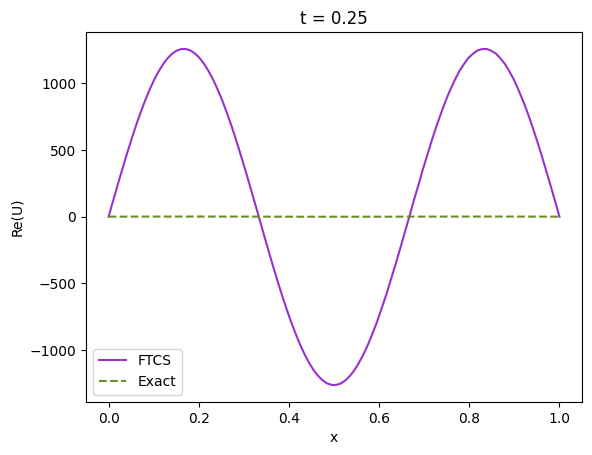

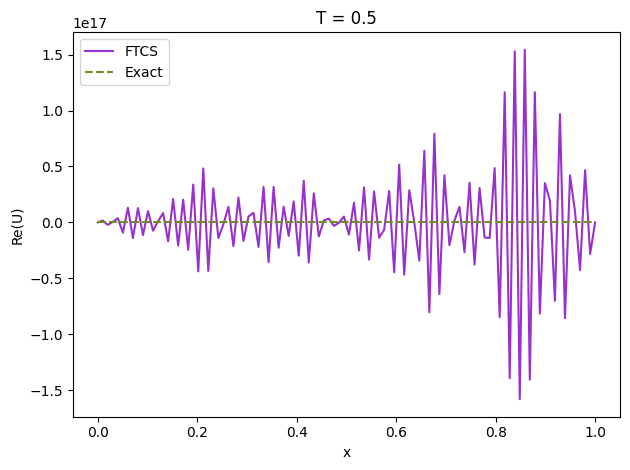

In [6]:
# determine all parameters
dt= 5*10**(-2) # delta t
dx = 10**(-2) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # inital condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(T/dt) +1
t1 = 0.25
idx = int(t1 / dt)

result1 = ftcs_schrodinger(u0, V0, dx, dt, tstep) # apply FTCS

#error
error1 = np.max(np.abs(result1[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error1)
error2 = np.max(np.abs(result1[-1,:] - exact(x,T)))
print("Error at t=0.5:", error2)


# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result1[idx]), color = "darkorchid", label='FTCS')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('FTCS1.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result1[-1]), color = "darkorchid", label='FTCS')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('FTCS2.png')

plt.tight_layout()
plt.show()


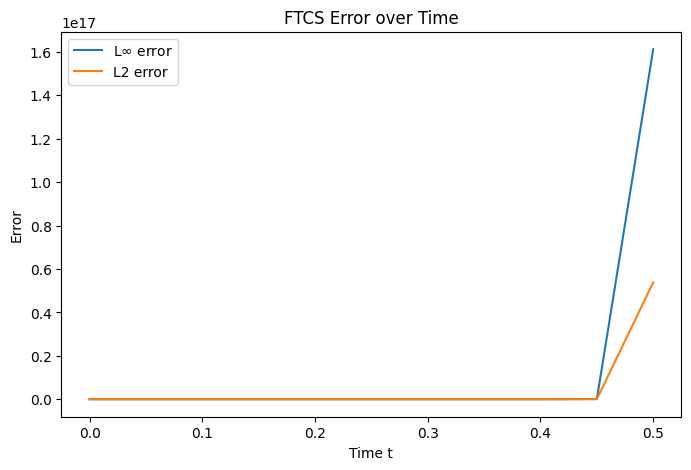

In [7]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result1, x, tstep, dt, dx)

#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('FTCS Error over Time')
plt.legend()
plt.savefig('FTCS_error1.png')
plt.show()

### $\Delta t = 5 \times 10^{-3}$ and $\Delta x = 10^{-2}$

Error at t=0.25: 1.0252296964831763e+99
Error at t=0.5: 4.0737484739315278e+211


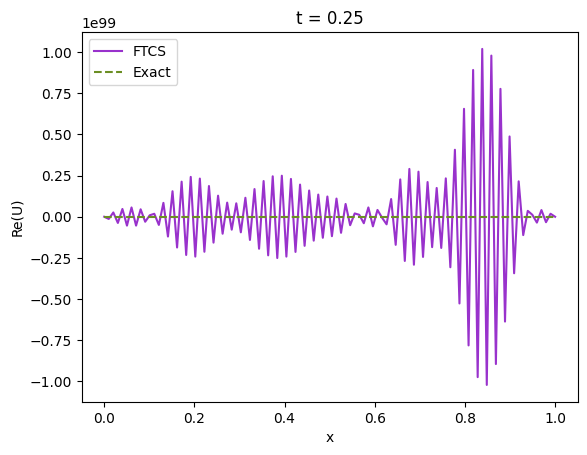

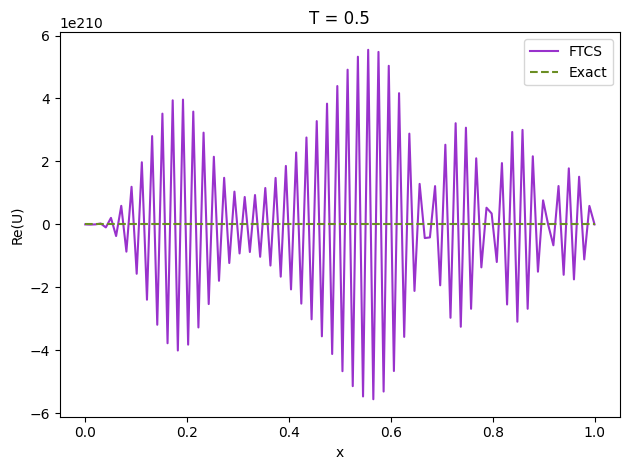

In [8]:
# determine all parameters
dt= 5*10**(-3) # delta t
dx = 10**(-2) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result2 = ftcs_schrodinger(u0, V0, dx, dt, tstep) # apply FTCS

#error
error3 = np.max(np.abs(result2[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error3)
error4 = np.max(np.abs(result2[-1,:] - exact(x,T)))
print("Error at t=0.5:", error4)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result2[idx]), color = "darkorchid", label='FTCS')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('FTCS3.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result2[-1]), color = "darkorchid", label='FTCS')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('FTCS4.png')

plt.tight_layout()
plt.show()

/var/folders/1d/b5lpmqbx325cjvrjtm3hlv380000gn/T/ipykernel_77509/635400012.py:9: RuntimeWarning: overflow encountered in square
  L2_error[t] = np.sqrt(np.sum(np.abs(result[t,:] - exact(x,t*dt))**2) * dx)
/Users/mariafdz/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


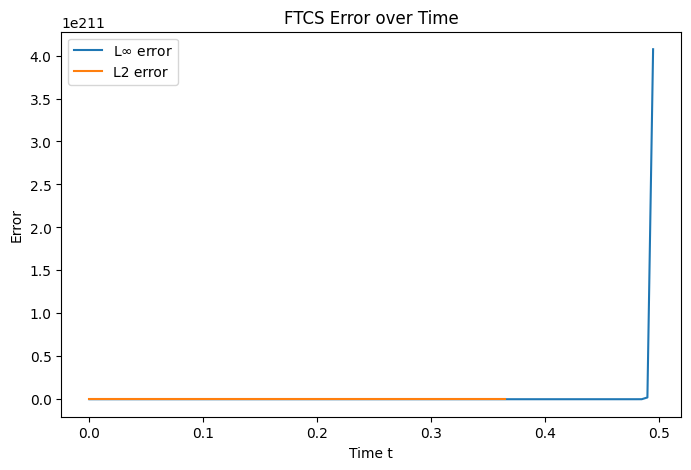

In [9]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result2, x, tstep, dt, dx)

#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.arange(0, T, dt), L2_inf, label='L$\infty$ error')
plt.plot(np.arange(0, T, dt), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('FTCS Error over Time')
plt.legend()
plt.savefig('FTCS_error2.png')
plt.show()

# DuFort-Frankel explicit mehtod 

In [10]:
# define the DuFort-Frankel explicit method
#for: du/dt = i*d**2u/dx**2 - i*V0*u
def dufort_frankel_schrodinger(u0, V0, dx, dt, tsteps, start=True):
    if start:
        u0 = ftcs_schrodinger(u0, V0, dx, dt, 2) # use ftcs for first iteration
        
    # define empty matrix of complex values
    U = np.zeros((tsteps, len(u0[0])), dtype=complex)

    U[0:2] = u0 # initial condition
    U[:, 0] = u0[0, 0] # left boundary condition
    U[:, -1] = u0[0, -1] # right boundary condition

    A = 2j * dt / dx**2 # coefficient 1
    B = 1j * V0 * dt #coefficient 2

    for t in range(1, tsteps - 1):
        u_k_next = U[t, 2:] # u_k+1
        u_k_prev  = U[t, :-2] # u_k-1
        u_n_prev  = U[t-1, 1:-1] # u_n-1

        # Dufort-Frankel 
        U[t+1, 1:-1] = ( A * (u_k_next + u_k_prev) + u_n_prev * ( 1 - A - B )) / ( 1 + A + B)

    return U

### $\Delta t = 5 \times 10^{-4}$ and $\Delta x = 10^{-4}$

Error at t=0.25: 18.968806886314315
Error at t=0.5: 33.164075406841924


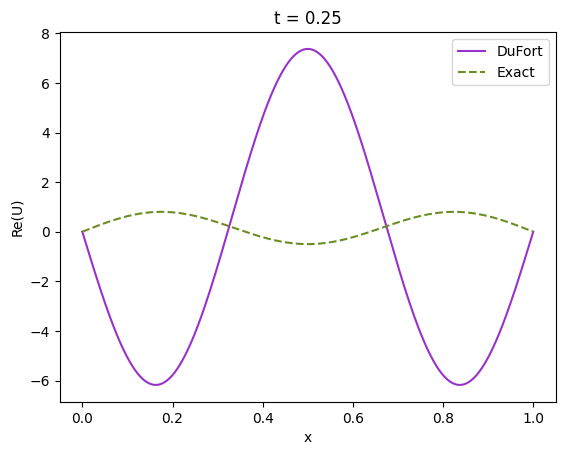

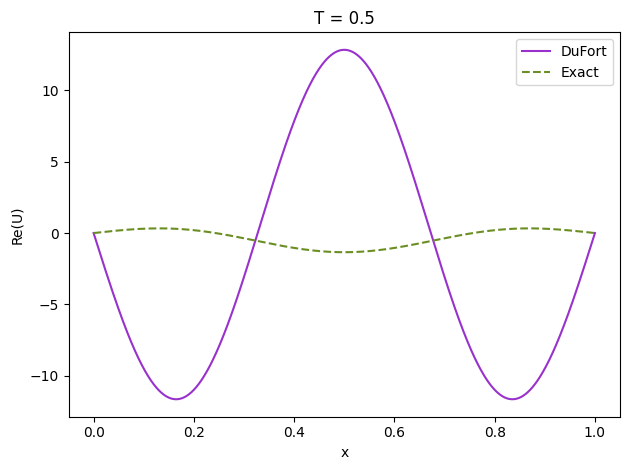

In [11]:
# determine all parameters
dt= 5*10**(-4) # delta t
dx = 10**(-4) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result3 = dufort_frankel_schrodinger(u0, V0, dx, dt, tstep, start=True) # apply DuFort-Frankel

# Error
error5 = np.max(np.abs(result3[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error5)
error6 = np.max(np.abs(result3[-1,:] - exact(x,T)))
print("Error at t=0.5:", error6)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result3[idx]), color = "darkorchid", label='DuFort')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('DF1.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result3[-1]), color = "darkorchid", label='DuFort')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('DF2.png')

plt.tight_layout()
plt.show()

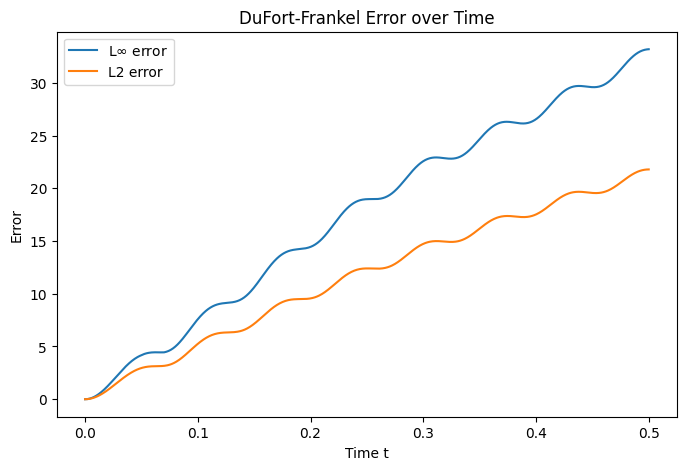

In [12]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result3, x, tstep, dt, dx)

#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('DuFort-Frankel Error over Time')
plt.legend()
plt.savefig('DF_error1.png')
plt.show()

### $\Delta t =  10^{-4}$ and $\Delta x = 10^{-2}$

Error at t=0.25: 0.13352259491384927
Error at t=0.5: 0.29984384084897087


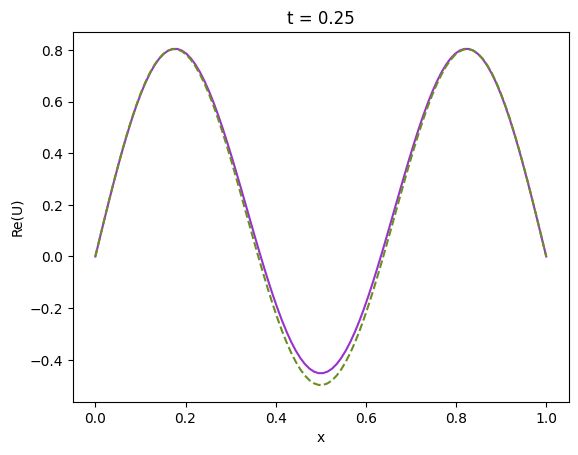

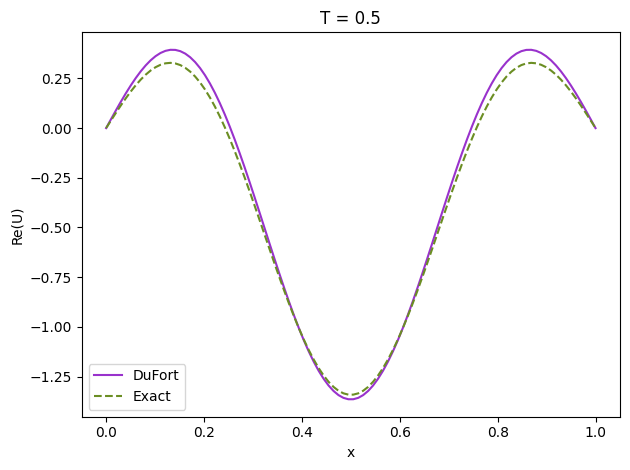

In [13]:
# determine all parameters
dt= 10**(-4) # delta t
dx = 10**(-2) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result4 = dufort_frankel_schrodinger(u0, V0, dx, dt, tstep, start=True) # apply DuFort-Frankel

# Error
error7 = np.max(np.abs(result4[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error7)
error8 = np.max(np.abs(result4[-1,:] - exact(x,T)))
print("Error at t=0.5:", error8)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result4[idx]), color = "darkorchid", label='DuFort')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend
plt.savefig('DF3.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result4[-1]), color = "darkorchid", label='DuFort')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('DF4.png')

plt.tight_layout()
plt.show()

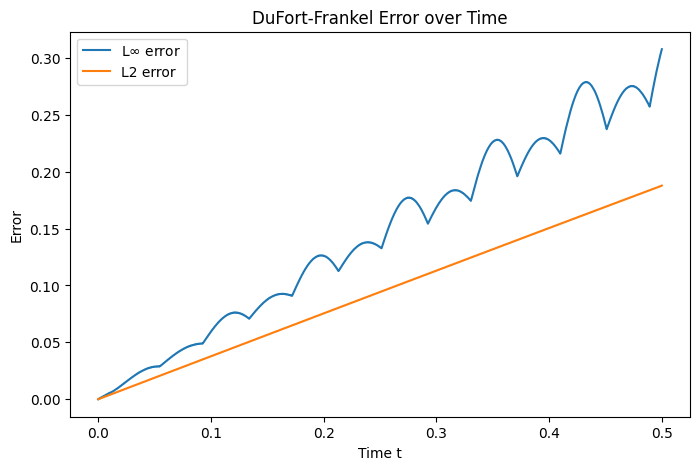

In [14]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result4, x, tstep, dt, dx)

#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('DuFort-Frankel Error over Time')
plt.legend()
plt.savefig('DF_error2.png')
plt.show()

# BTCS (Laasonen) implicit method

In [15]:
# define the BTCS Laasonen implicit method
#for: du/dt = i*d**2u/dx**2 - i*V0*u
def laasonen_schrodinger(u0, V0, dx, dt, tsteps, large=True):
    N = len(u0) - 2       # number of interior points
    U = np.zeros((tsteps, len(u0)), dtype=complex) # empty complex matrix to save results

    U[0]    = u0
    U[:, 0] = u0[0]
    U[:,-1] = u0[-1]

    A = 1j * dt / dx**2   # off-diagonal coefficient
    B = 1 + 2*A + 1j*V0*dt  # main diagonal coefficient

    # Build tridiagonal matrix
    diag  = np.full(N, B) # main diagonal
    off   = np.full(N - 1, -A) # off diagonal
    M     = np.diag(diag) + np.diag(off, k=1) + np.diag(off, k=-1)
    
    ab = np.zeros((3, N), dtype=complex)
    ab[0, 1:]  = -A   # upper diagonal
    ab[1, :]   =  B   # main diagonal
    ab[2, :-1] = -A   # lower diagonal

    for t in range(tsteps - 1):
        rhs = U[t, 1:-1].copy()
        rhs[0]  += A * U[t, 0] # left boundary conditon
        rhs[-1] += A * U[t, -1] # right boundary condition

        U[t+1, 1:-1] = solve_banded((1, 1), ab, rhs)


    return U

### $\Delta t = 10^{-3}$ and $\Delta x = 10^{-3}$

Error at t=0.25: 0.4963161355291652
Error at t=0.5: 0.683078274031964


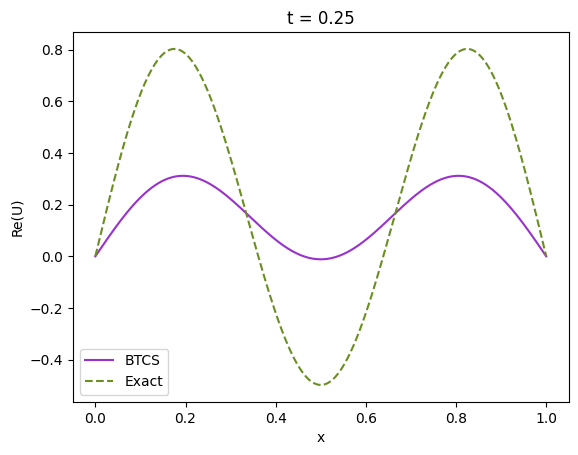

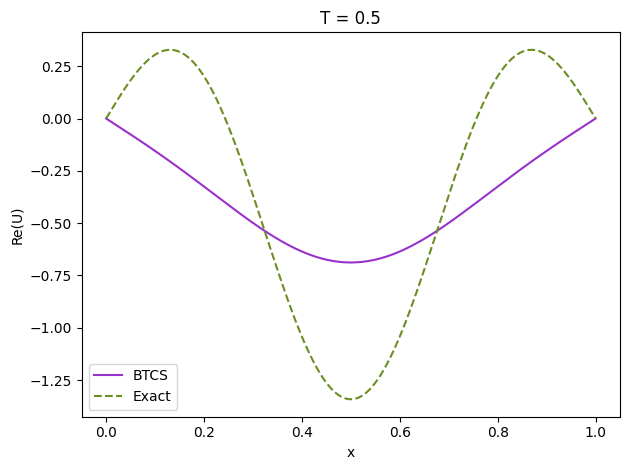

In [16]:
# determine all parameters
dt= 10**(-3) # delta t
dx = 10**(-3) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result5 = laasonen_schrodinger(u0, V0, dx, dt, tstep, large=True) # apply BTCS

# Error
error9 = np.max(np.abs(result5[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error9)
error10 = np.max(np.abs(result5[-1,:] - exact(x,T)))
print("Error at t=0.5:", error10)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result5[idx]), color = "darkorchid", label='BTCS')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('BTCS1.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result5[-1]), color = "darkorchid", label='BTCS')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('BTCS2.png')

plt.tight_layout()
plt.show()

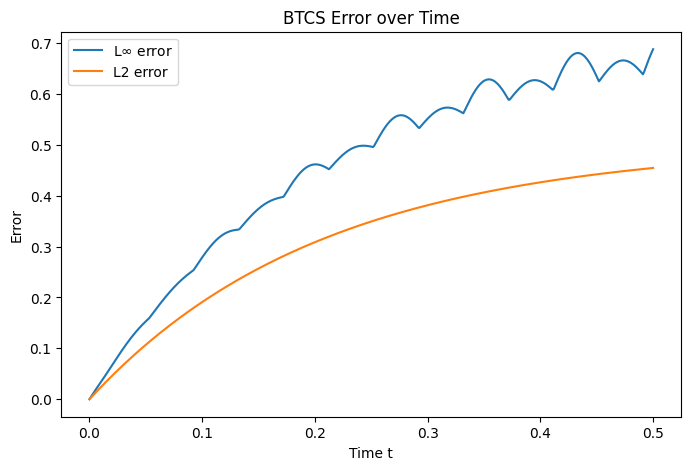

In [17]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result5, x, tstep, dt, dx)

#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('BTCS Error over Time')
plt.legend()
plt.savefig('BCS_error1.png')
plt.show()

### $\Delta t =  5 \times 10^{-4}$ and $\Delta x = 10^{-4}$

Error at t=0.25: 0.32180186281061884
Error at t=0.5: 0.5142446273438723


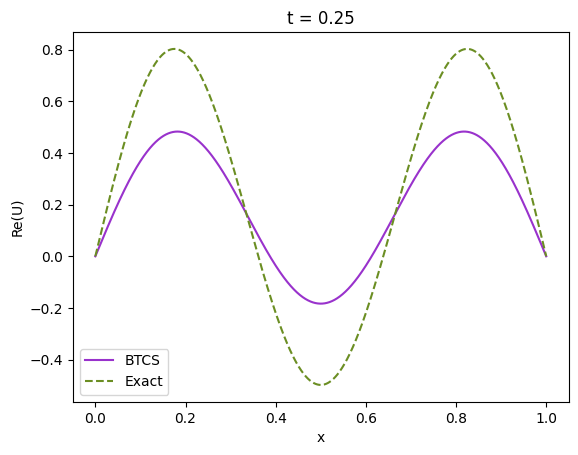

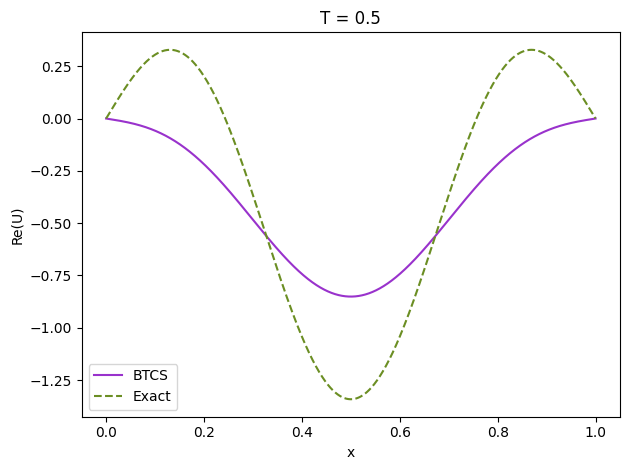

In [18]:
# determine all parameters
dt= 5*10**(-4) # delta t
dx = 10**(-4) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result6 = laasonen_schrodinger(u0, V0, dx, dt, tstep, large=True) # apply BTCS

# Error
error11 = np.max(np.abs(result6[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error11)
error12 = np.max(np.abs(result6[-1,:] - exact(x,T)))
print("Error at t=0.5:", error12)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result6[idx]), color = "darkorchid", label='BTCS')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('BTCS3.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result6[-1]), color = "darkorchid", label='BTCS')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('BTCS4.png')

plt.tight_layout()
plt.show()

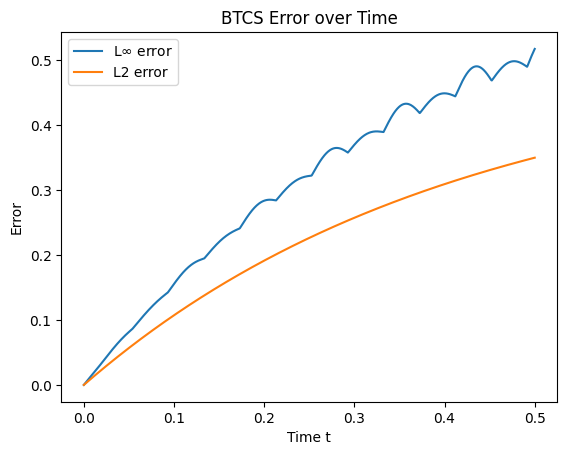

In [19]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result6, x, tstep, dt, dx)

#plot error over time
plt.figure()
plt.plot(np.linspace(0, T, int(T/dt)), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('BTCS Error over Time')
plt.legend()
plt.savefig('BTCS_error2.png')
plt.show()

# Crank Nicolson implicit mehtod 

In [20]:
# define the Crank Nicolson implicit method
#for: du/dt = i*d**2u/dx**2 - i*V0*u
def crank_nicolson_schrodinger(u0, V0, dx, dt, tsteps):
    U = np.zeros((tsteps, len(u0)), dtype=complex) # empty complex matrix

    U[0]    = u0 # initial condition
    U[:, 0] = u0[0] # left boundary condition
    U[:,-1] = u0[-1] # right boundary condition

    A = 1j * dt / (2 * dx**2)  # coefficient 1
    B = 1j * V0 * dt / 2       # coefficient 2

    # tridiagonal matrix 
    N   = len(u0) - 2
    ab  = np.zeros((3, N), dtype=complex)
    ab[0, 1:]  = -A          # upper diagonal
    ab[1, :]   = 1 + 2*A + B # main diagonal
    ab[2, :-1] = -A          # lower diagonal

    for t in range(tsteps - 1):
        u_k     = U[t, 1:-1]
        u_k_next = U[t, 2:]
        u_k_prev  = U[t, :-2]

        # RHS
        rhs = A*u_k_prev + (1 - 2*A - B)*u_k + A*u_k_next

        
        rhs[0]  += A * U[t, 0] # left boundary condition
        rhs[-1] += A * U[t, -1] # right boundary condition

        U[t+1, 1:-1] = solve_banded((1, 1), ab, rhs)

    return U

### $\Delta t = 10^{-3}$ and $\Delta x = 10^{-3}$

Error at t=0.25: 0.017414660445169653
Error at t=0.5: 0.0409255402440274


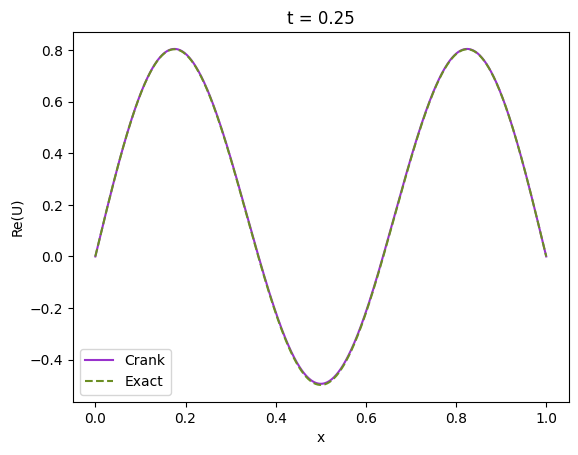

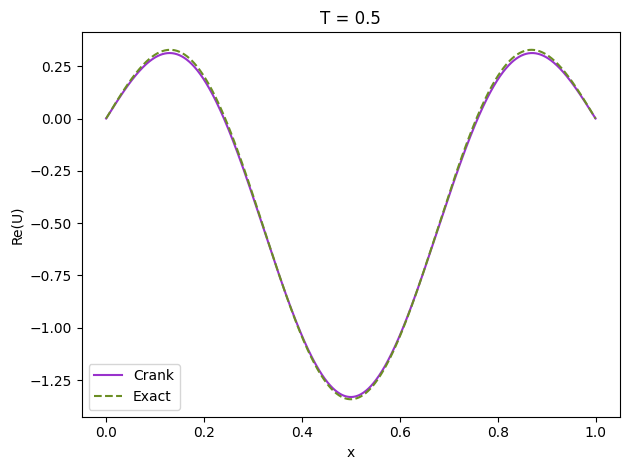

In [21]:
# determine all parameters
dt= 10**(-3) # delta t
dx = 10**(-3) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result7 = crank_nicolson_schrodinger(u0, V0, dx, dt, tstep) # apply Crank Nicolson

# Error
error13 = np.max(np.abs(result7[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error13)
error14 = np.max(np.abs(result7[-1,:] - exact(x,T)))
print("Error at t=0.5:", error14)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result7[idx]), color = "darkorchid", label='Crank')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('CN1.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result7[-1]), color = "darkorchid", label='Crank')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('CN2.png')

plt.tight_layout()
plt.show()

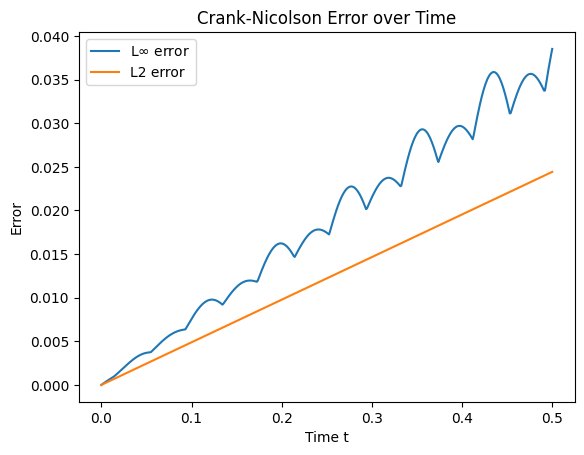

In [22]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result7, x, tstep, dt, dx)

#plot error over time
plt.figure()
plt.plot(np.linspace(0, T, int(T/dt)), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Crank-Nicolson Error over Time')
plt.legend()
plt.savefig('CN_error1.png')
plt.show()

### $\Delta t = 5 \times 10^{-4}$ and $\Delta x = 10^{-4}$

Error at t=0.25: 0.0006075302246340409
Error at t=0.5: 0.04012430408635161


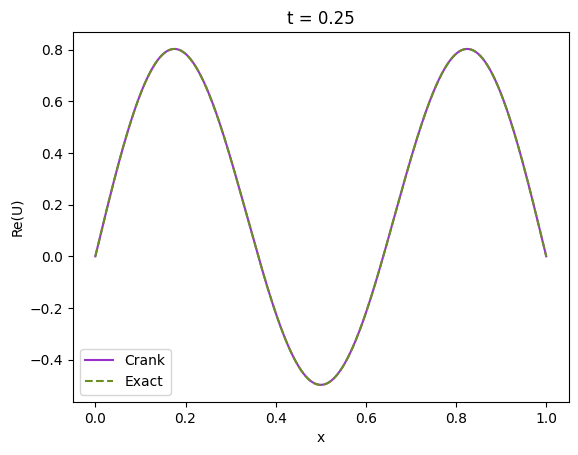

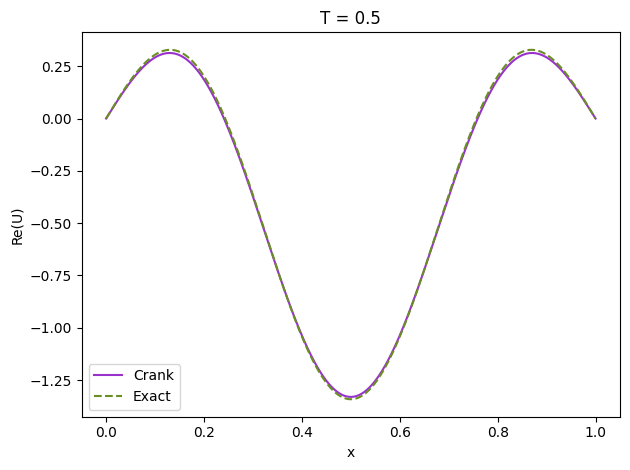

In [23]:
# determine all parameters
dt= 5*10**(-4) # delta t
dx = 10**(-4) # delta x
lent = int(1/dx)
x = np.linspace(0, 1, lent)
u0 = 0.8* np.sin(np.pi*x)+0.7*np.exp(-1j*np.pi/7)*np.sin(3*np.pi*x) # initial condition
V0 = 10 # potential
T = 0.5 # final time
tstep = int(0.5/dt)
t1 = 0.25
idx = int(t1 / dt)

result8 = crank_nicolson_schrodinger(u0, V0, dx, dt, tstep) # apply Crank Nicolson

# Error
error15 = np.max(np.abs(result8[idx,:] - exact(x,t1)))
print("Error at t=0.25:", error15)
error16 = np.max(np.abs(result8[-1,:] - exact(x,T)))
print("Error at t=0.5:", error16)

# plot results vs exact solution
# t = 0.25
plt.figure()
plt.plot(x, np.real(result8[idx]), color = "darkorchid", label='Crank')
plt.plot(x, np.real(exact(x, t1)), '--', color = "olivedrab", label='Exact')
plt.title('t = 0.25')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('CN3.png')

# t = 0.5
plt.figure()
plt.plot(x, np.real(result8[-1]), color = "darkorchid", label='Crank')
plt.plot(x, np.real(exact(x, T)), '--', color = "olivedrab", label='Exact')
plt.title('T = 0.5')
plt.xlabel('x')
plt.ylabel('Re(U)')
plt.legend()
plt.savefig('CN4.png')

plt.tight_layout()
plt.show()

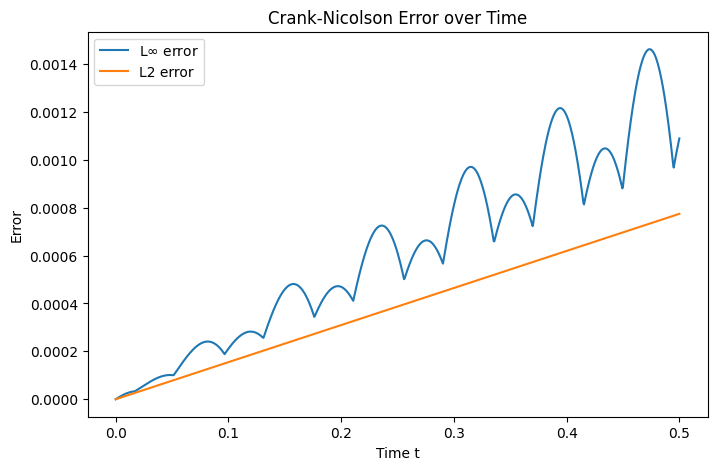

In [24]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result8, x, tstep, dt, dx)

#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Crank-Nicolson Error over Time')
plt.legend()
plt.savefig('CN_error2.png')
plt.show()